<div align="center">
  <img src="../assets/uepb_logo.png" width="150">
  <br>
  <strong>Universidade Estadual da Paraíba (UEPB)</strong><br>
  <strong>Professor(a):</strong> Thiciany Matsudo Iwano<br>
  <strong>Alunos:</strong> Tarcio Elyakin Agra Diniz & Djhonatah Wesley Cavalcanti Alves<br>
  <strong>Série:</strong> Sistemas Lineares: teoria, interpretação geométrica e aplicações com Python<br>
</div>

---

# [Tutorial 07] Aplicação: Interpolação Polinomial

> **Pré-requisito:** [06] Aplicação: Fluxo de Tráfego (`06_aplicacao_fluxo_trafego.ipynb`)  
> **Próximo:** [08] Prática: Exercícios Resolvidos (`08_pratica_exercicios_resolvidos.ipynb`)

---

## Introdução

Você já se perguntou como o computador desenha uma curva suave entre pontos dispersos? Como podemos prever o que acontece entre duas medições experimentais?

Neste tutorial, vamos explorar a **Interpolação Polinomial**. Você descobrirá que encontrar o polinômio perfeito que passa por um conjunto de pontos nada mais é do que resolver um sistema linear especial. Para isso, utilizaremos uma ferramenta matemática clássica: a **Matriz de Vandermonde**.

Ao final deste tutorial, você será capaz de:
1. Formular o problema de interpolação como um sistema $Ax = b$.
2. Construir e utilizar a **Matriz de Vandermonde**.
3. Implementar um interpolador polinomial do zero usando NumPy.
4. Compreender as limitações da interpolação de alto grau (Fenômeno de Runge).

---

## 1. O Problema da Interpolação

Imagine que você possui $n$ pontos no plano cartesiano: $(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)$, onde todos os $x_i$ são distintos. O objetivo da **interpolação polinomial** é encontrar um polinômio $P(x)$ de grau no máximo $n-1$ tal que:

$$P(x_i) = y_i, \quad \text{para } i = 1, 2, \dots, n$$

Seja o polinômio genérico de grau $n-1$:
$$P(x) = a_0 + a_1x + a_2x^2 + \dots + a_{n-1}x^{n-1}$$

As incógnitas que queremos determinar são os coeficientes $a_0, a_1, \dots, a_{n-1}$.

---

## 2. Construindo o Sistema Linear

Para cada ponto $(x_i, y_i)$, temos uma equação:

1. $a_0 + a_1x_1 + a_2x_1^2 + \dots + a_{n-1}x_1^{n-1} = y_1$
2. $a_0 + a_1x_2 + a_2x_2^2 + \dots + a_{n-1}x_2^{n-1} = y_2$
...
n. $a_0 + a_1x_n + a_2x_n^2 + \dots + a_{n-1}x_n^{n-1} = y_n$

Isso pode ser escrito na forma matricial $V\mathbf{a} = \mathbf{y}$:

$$
\begin{pmatrix}
1 & x_1 & x_1^2 & \dots & x_1^{n-1} \\
1 & x_2 & x_2^2 & \dots & x_2^{n-1} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_n & x_n^2 & \dots & x_n^{n-1}
\end{pmatrix}
\begin{pmatrix}
a_0 \\
a_1 \\
\vdots \\
a_{n-1}
\end{pmatrix}
=
\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{pmatrix}
$$

A matriz à esquerda é conhecida como **Matriz de Vandermonde**. Se os valores de $x$ forem distintos, essa matriz é invertível, garantindo a existência e unicidade do polinômio interpolador.

---

## 3. Implementação em Python

Vamos utilizar NumPy para lidar com os cálculos numéricos e Matplotlib para visualização.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo Seaborn 'whitegrid' para interpolação
sns.set_theme(style="whitegrid", context="talk", palette="deep")

# 1. Definindo os pontos (exemplo)
x_pontos = np.array([0, 1, 2, 4, 5])
y_pontos = np.array([1, 3, 3, 4, 2])

# 2. Construindo a Matriz de Vandermonde
# Podemos usar np.vander(x_pontos, increasing=True)
V = np.vander(x_pontos, increasing=True)

print("Matriz de Vandermonde (V):")
print(V)

# 3. Resolvendo o sistema Va = y para encontrar os coeficientes 'a'
# Usamos np.linalg.solve para resolver o sistema linear
coeficientes = np.linalg.solve(V, y_pontos)

print("\nCoeficientes do polinômio [a0, a1, ..., an-1]:")
print(coeficientes)


Matriz de Vandermonde (V):
[[  1   0   0   0   0]
 [  1   1   1   1   1]
 [  1   2   4   8  16]
 [  1   4  16  64 256]
 [  1   5  25 125 625]]

Coeficientes do polinômio [a0, a1, ..., an-1]:
[ 1.          4.45       -3.39166667  1.05       -0.10833333]


### Visualizando o Resultado


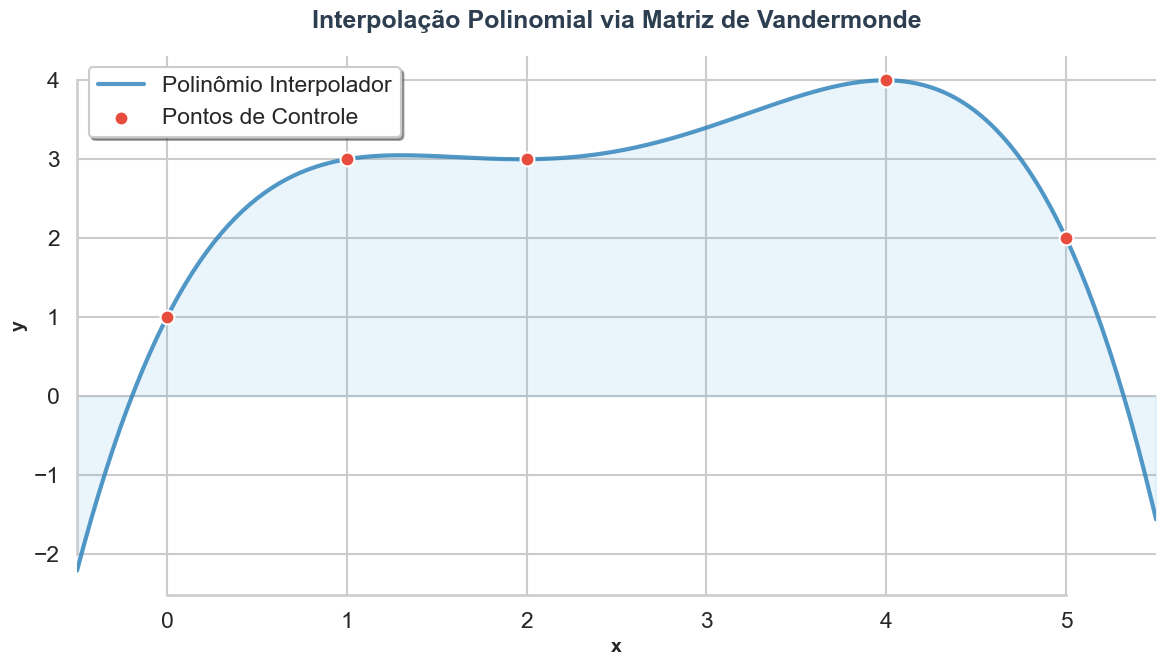

In [2]:
# Criando uma malha fina para desenhar a curva do polinômio
x_curva = np.linspace(min(x_pontos)-0.5, max(x_pontos)+0.5, 300)

# Avaliando o polinômio na curva: P(x) = sum(a_i * x^i)
# Usando np.polyval (precisa inverter os coeficientes pois polyval espera ordem decrescente)
y_curva = np.polyval(coeficientes[::-1], x_curva)

plt.figure(figsize=(12, 7))

# Plot da curva suave com Seaborn
sns.lineplot(x=x_curva, y=y_curva, label='Polinômio Interpolador', 
             color='#2980b9', linewidth=3, alpha=0.8)

# Pontos de controle com destaque
plt.scatter(x_pontos, y_pontos, color='#e74c3c', s=100, label='Pontos de Controle', 
            zorder=5, edgecolor='white', linewidth=1.5)

# Áreas de preenchimento sutil para beleza
plt.fill_between(x_curva, y_curva, alpha=0.1, color='#3498db')

# Detalhes Estéticos
plt.title('Interpolação Polinomial via Matriz de Vandermonde', 
          fontsize=18, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('x', fontsize=14, fontweight='bold')
plt.ylabel('y', fontsize=14, fontweight='bold')

# Legenda elegante
plt.legend(frameon=True, shadow=True, facecolor='white')

# Ajuste fino de eixos
plt.xlim(min(x_curva), max(x_curva))
sns.despine(trim=True)

plt.tight_layout()
plt.show()


## 4. Validação Computacional

Podemos validar se o polinômio realmente passa pelos pontos originais calculando o erro residual.


In [3]:
y_predito = np.zeros_like(x_pontos, dtype=float)
for i, a in enumerate(coeficientes):
    y_predito += a * (x_pontos**i)

erro_total = np.sum(np.abs(y_predito - y_pontos))
print(f"Erro residual total nos pontos de controle: {erro_total:.2e}")


Erro residual total nos pontos de controle: 4.88e-15


## 5. Limitações: Ruído e Oscilações

### Fenômeno de Runge
Ao aumentar o número de pontos (e consequentemente o grau do polinômio), o polinômio interpolador pode começar a apresentar oscilações selvagens nas extremidades do intervalo. Isso é conhecido como **Fenômeno de Runge**.

### Dados Inconsistentes ou Ruído
Se os dados vierem de medições experimentais com ruído, forçar o polinômio a passar *exatamente* por todos os pontos pode levar a um modelo que "decora" o ruído em vez de capturar a tendência (overfitting).

### Extensão: Mínimos Quadrados
Quando temos muitos pontos ou dados ruidosos, é preferível encontrar um polinômio de **baixo grau** que se aproxime dos pontos, minimizando a soma dos quadrados dos erros, em vez de passar por todos eles. Isso nos leva ao método de **Mínimos Quadrados**, que será o tema do nosso próximo notebook.

---

## 6. Conclusão

Neste notebook, vimos que:
1. A interpolação polinomial é, no fundo, a resolução de um sistema linear específico.
2. A **Matriz de Vandermonde** estrutura as potências de $x$ para relacionar coeficientes e resultados.
3. Embora matematicamente elegante, a interpolação de alto grau pode ser instável e sensível a ruído.


---
## Próximo Passo

A interpolação nos mostrou o poder das matrizes para ajustar modelos matemáticos aos dados. No próximo tutorial, faremos uma pausa para consolidar tudo o que aprendemos: resolveremos uma série de exercícios práticos, comparando o raciocínio manual (passo a passo) com a eficiência do Python.

👉 **[Ir para o Tutorial 08: Prática: Exercícios Resolvidos](./08_pratica_exercicios_resolvidos.ipynb)**
